## 1.	Titulo: Modelo de predicción de ocurrencia de accidentes de tránsito en Risaralda mediante datos históricos.

In [ ]:
#!/usr/bin/env python
# coding: utf-8

El presente trabajo se enfoca en la utilización de técnicas avanzadas de analítica de datos para abordar una problemática crítica y de gran relevancia social como lo son los accidentes de tránsito en la ciudad de Pereira, capital del departamento de Risaralda. Esta investigación surge de la necesidad de comprender mejor los factores que contribuyen a estos incidentes, que no solo representan un desafío para la seguridad vial sino que también tienen un profundo impacto humano y económico en la comunidad.

Con el objetivo de contribuir a la reducción de las muertes y lesiones graves derivadas de accidentes de tránsito, este estudio se propone identificar los puntos críticos donde estos incidentes son más frecuentes, así como los factores de riesgo que aumentan su probabilidad. Esta identificación se realizará mediante datos históricos  provenientes del Instituto Nacional de Medicina Legal y Ciencias Forenses.


Objetivos:

•	Identificación de puntos críticos de accidentes de transito.

•	Identificación de factores de influencia en accidentes de tránsito.

•	Proponer estrategias para la prevención de accidentes de tránsito en Risaralda.

Presnetacion detallada de la base de datos:

Se cuenta con la base de datos de tipo CSV aportada por medicina legal con datos de accidentes fatales desde el año 2023 al 2025 (xxxxregistros aprox.) en la cual contamos con datos asociados a la víctima de tipo cualitativas como sexo, estado civil, nivel académico, ocupación y cuantitativas como edad; adicionalmente contamos con datos cualitativos asociados a los hechos del accidente como fecha, hora, municipio, ubicación geográfica, tipo de la vía, case de accidente, tipo de vehículo, condición de lugar, entre otros.

En algunos casos no se cuenta con datos como la hora de los hechos, estado de la via, tipo de vehículo (vehículo fantasma) o condición de la vía debido a que no hay testigos que pudieran aportar dicha información o también se pueden encontrar datos atípicos que podrían ser generados en la digitación del informe pericial como por ejemplo edades de mas de 100 años.


In [ ]:
!pip install osmnx

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import LabelEncoder
import folium
from folium.plugins import HeatMap
import re
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
from shapely.geometry import Point
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
import pandas as pd

file_path = '/content/Fatales Pereira 2023-2025 2.xlsx'
df = pd.read_excel(file_path, sheet_name='BASE')

print(df.columns.tolist())

['ID', 'REGIONAL', 'SECCIONAL', 'UNIDAD BASICA', 'DEPARTAMENTO DE ATENCION', 'MUNICIPIO DE ATENCION', 'NUMERO DE RADICADO', 'TIPO DE CASO', 'SEXO', 'EDAD CALCULADA EN AÑOS', 'RANGO DE EDAD', 'UNIDAD DE EDAD', 'MENOR-MAYOR DE EDAD', 'ESTADO CONYUGAL', 'NIVEL ACADEMICO', 'PAIS DE NACIMIENTO', 'DEPARTAMENTO DE NACIMIENTO', 'MUNICIPIO DE NACIMIENTO', 'ANCESTRO RACIAL', 'PERTENENCIA GRUPAL', 'FECHA DEL HECHO', 'Fecha de los Hechos(reporte)', 'SE CONOCE HORA DEL HECHO', 'HORA DEL HECHO', 'Hora de los Hechos(reporte)', 'RANGO HORA DEL HECHO', 'PRESUNTO AGRESOR', 'PAIS DEL HECHO', 'DEPARTAMENTO DEL HECHO', 'MUNICIPIO DEL HECHO', 'BARRIO DEL HECHO', 'DIRECCION DEL HECHO', 'Direccion Completa', 'Latitude', 'Longitude', 'LOCALIDAD DEL HECHO', 'ZONA DEL HECHO', 'CIRCUNSTANCIA DEL HECHO', 'CIRCUNSTANCIA DEL HECHO RECODIFICADA', 'ESCENARIO DEL HECHO', 'MANERA DE MUERTE DEFINITIVA', 'CAUSA DE MUERTE DEFINITIVA', 'CLASE DE SINIESTRO', 'CONDICION DE LA VICTIMA', 'VEHICULO', 'TIPO DE SERVICIO DEL VEHICU

## Revisión de valores nulos

<Axes: >

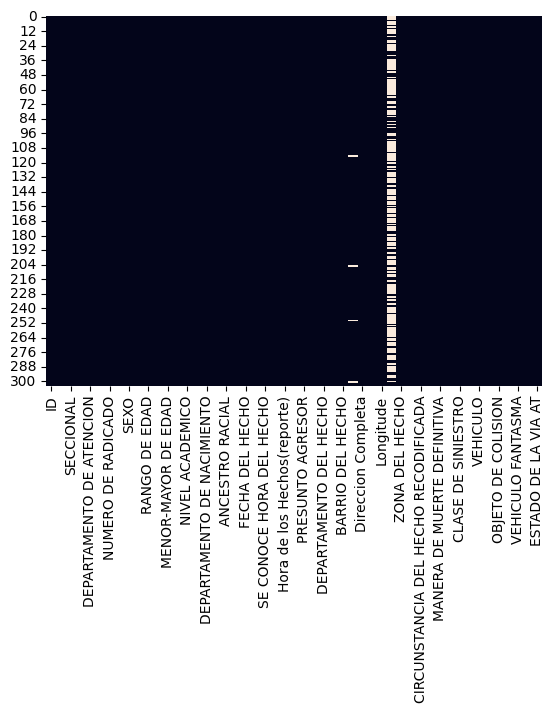

In [ ]:
sns.heatmap(df.isnull(), cbar=False)

Transformacion de columnas

Conversión a numérico: El primer bucle Utiliza pd.to_numeric() para convertir los valores de estas columnas a números, lo que es útil si los datos se importaron como cadenas de texto o si hay valores no numéricos que deben ser manejados. El argumento.

In [ ]:
for i in ['ID','NUMERO DE RADICADO','EDAD CALCULADA EN AÑOS','Latitude','Longitude']:
    df[i] = pd.to_numeric(df[i], errors='coerce')

Conversión a datetime: El segundo bucle for es para convertir los valores de estas columnas a objetos de fecha y hora de pandas.

In [ ]:
for i in ['FECHA DEL HECHO']:
    df[i]=pd.to_datetime(df[i], errors='coerce')

Eliminación de columnas: el código elimina las siguientes columnas del DataFrame que no se necesitan para el análisis. 'NUMERO DE RADICADO', 'UNIDAD DE EDAD', 'CAUSA DE MUERTE DEFINITIVA', 'MECANISMO DE MUERTE', 'AÑO DE RADICADO', 'HORA DE LOS HECHOS', 'DIAGNOSTICO TOPOGRAFICO', 'DEPARTAMENTO ASOCIADO A LA NECROPSIA', y elimina las filas donde la fecha de los hechos es NaN.


In [ ]:
!pip install geopy

In [ ]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd

geolocator = Nominatim(user_agent="perei_mapper")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def obtener_lat_lon(direccion):
    if pd.isna(direccion):
        return None, None

    consulta = f"{direccion}, Pereira, Risaralda, Colombia"
    location = geocode(consulta)

    if location:
        return location.latitude, location.longitude
    else:
        return None, None

# Aplica la función a la columna de dirección
df[['latitud', 'longitud']] = df['DIRECCION DEL HECHO'].apply(
    lambda x: pd.Series(obtener_lat_lon(x))
)

In [ ]:
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

Descripción de variables

* count: Muestra el número de observaciones no nulas para cada variable.
* mean: El valor medio de cada variable.
* std: La desviación estándar de cada variable, que es una medida de la cantidad de variación o dispersión de un conjunto de valores.
* min: El valor mínimo en cada variable.
* 25%: El percentil 25 o cuartil inferior, que indica que el 25% de los datos son menores que este valor.
* 50%: El percentil 50 o mediana, que es el valor medio de los datos.
* 75%: El percentil 75 o cuartil superior, que indica que el 75% de los datos son menores que este valor.
* max: El valor máximo en cada variable.

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,304.0,6411.569079,4496.0,5794.5,6403.0,7039.75,7673.0,750.089078
NUMERO DE RADICADO,304.0,2024046350244901632.0,2023010166000999936.0,2023010166001000704.0,2024010166001000448.0,2025010166001000192.0,2025010166001000960.0,813666177886577.375
EDAD CALCULADA EN AÑOS,304.0,47.398572,0.166,26.75,45.0,66.0,91.0,21.965705
FECHA DEL HECHO,304,2024-07-26 07:20:31.578947328,2023-01-01 00:00:00,2023-10-28 18:00:00,2024-08-17 12:00:00,2025-04-24 06:00:00,2025-12-24 00:00:00,NaN
HORA DEL HECHO,304,2024-07-26 07:20:31.578947328,2023-01-01 00:00:00,2023-10-28 18:00:00,2024-08-17 12:00:00,2025-04-24 06:00:00,2025-12-24 00:00:00,NaN
Latitude,304.0,4.802419,3.41787,4.804077,4.808717,4.813423,4.843908,0.08192
Longitude,304.0,-75.727614,-76.507966,-75.74037,-75.699625,-75.690601,-75.612801,0.071677
hora,304.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.describe(include=['O']).T

,count,unique,top,freq
REGIONAL,304,1,Dirección regional occidente,304
SECCIONAL,304,1,Dirección seccional Risaralda,304
UNIDAD BASICA,304,2,PEREIRA,303
DEPARTAMENTO DE ATENCION,304,2,RISARALDA,303
MUNICIPIO DE ATENCION,304,2,PEREIRA,303
TIPO DE CASO,304,1,NECROPSIA,304
SEXO,304,2,MASCULINO,251
RANGO DE EDAD,304,17,(20 a 24),34
UNIDAD DE EDAD,304,2,Años,303
MENOR-MAYOR DE EDAD,304,2,b) Mayores de Edad (>18 años),291


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 52 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   ID                                    304 non-null    int64         
 1   REGIONAL                              304 non-null    object        
 2   SECCIONAL                             304 non-null    object        
 3   UNIDAD BASICA                         304 non-null    object        
 4   DEPARTAMENTO DE ATENCION              304 non-null    object        
 5   MUNICIPIO DE ATENCION                 304 non-null    object        
 6   NUMERO DE RADICADO                    304 non-null    int64         
 7   TIPO DE CASO                          304 non-null    object        
 8   SEXO                                  304 non-null    object        
 9   EDAD CALCULADA EN AÑOS                304 non-null    float64       
 10  RA

Gráfico de densidad

/tmp/ipython-input-678546474.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best', title='VEHICULO', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
/tmp/ipython-input-678546474.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="VEHICULO", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)


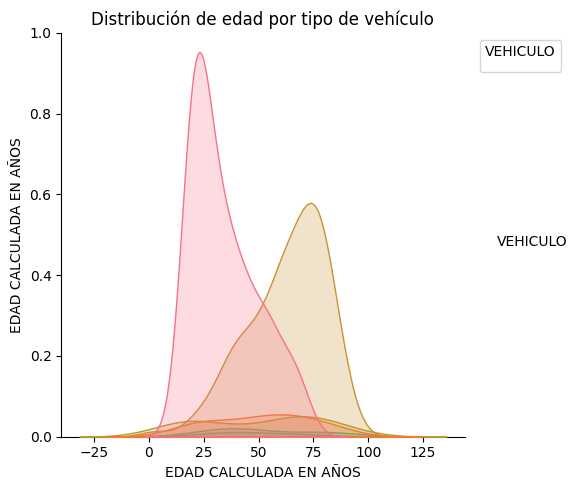

In [ ]:
df_subset = df[['EDAD CALCULADA EN AÑOS', 'VEHICULO']]

pairplot_ = sns.pairplot(df_subset, hue='VEHICULO', height=5)
plt.legend(loc='best', title='VEHICULO', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

plt.title("Distribución de edad por tipo de vehículo")
plt.xlabel("Edad (años)")
plt.ylabel("Densidad")
plt.legend(title="VEHICULO", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

Gráficos boxplot

Boxplot Sexo - Edad


<Axes: xlabel='SEXO', ylabel='EDAD CALCULADA EN AÑOS'>

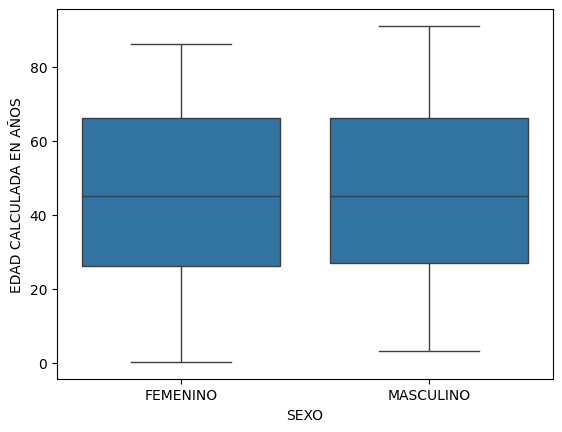

In [ ]:
sns.boxplot(x=df['SEXO'],y=df['EDAD CALCULADA EN AÑOS'])

Tipo de servicio de vehículo - Edad

<Axes: xlabel='TIPO DE SERVICIO DEL VEHICULO', ylabel='EDAD CALCULADA EN AÑOS'>

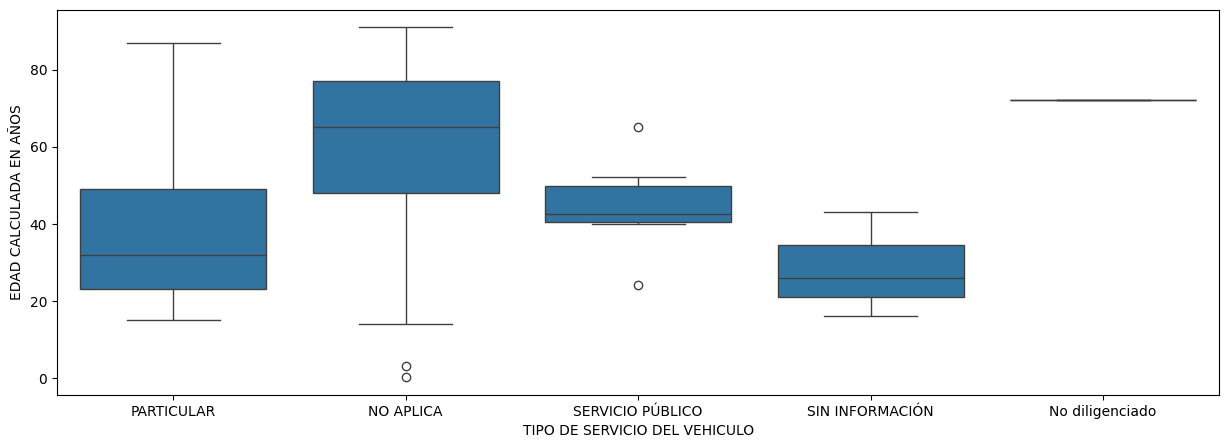

In [ ]:
plt.figure(figsize=[15,5])
sns.boxplot(x=df['TIPO DE SERVICIO DEL VEHICULO'],y=df['EDAD CALCULADA EN AÑOS'])

Boxplot: Vehículo - Edad

<Axes: xlabel='VEHICULO', ylabel='EDAD CALCULADA EN AÑOS'>

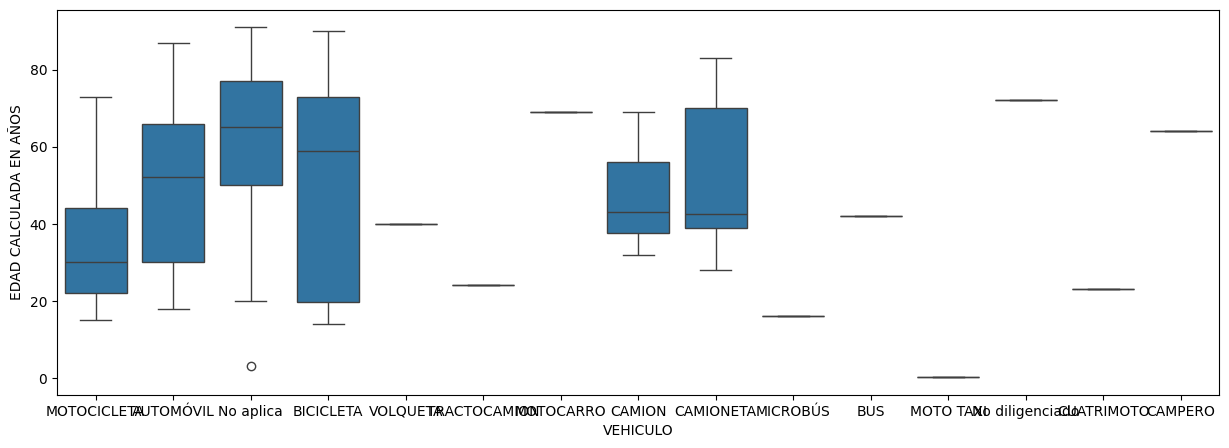

In [ ]:
plt.figure(figsize=[15,5])
sns.boxplot(x=df['VEHICULO'],y=df['EDAD CALCULADA EN AÑOS'])

Gráfico de barras

Tipo de vehículo.

<Axes: xlabel='VEHICULO'>

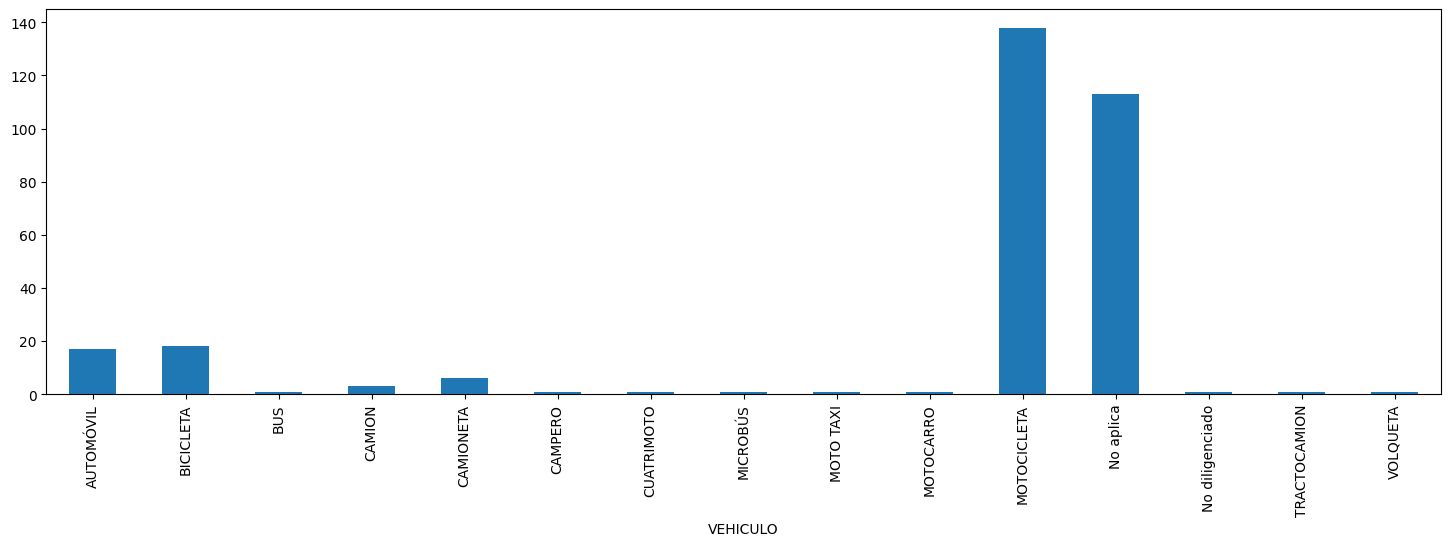

In [ ]:
plt.figure(figsize=[18,5])
df.groupby('VEHICULO')['VEHICULO'].count().plot(kind='bar')

In [ ]:
df['Hora de los Hechos(reporte)'] = pd.to_datetime(df['Hora de los Hechos(reporte)'], errors='coerce')
df['hora'] = df['Hora de los Hechos(reporte)'].dt.hour

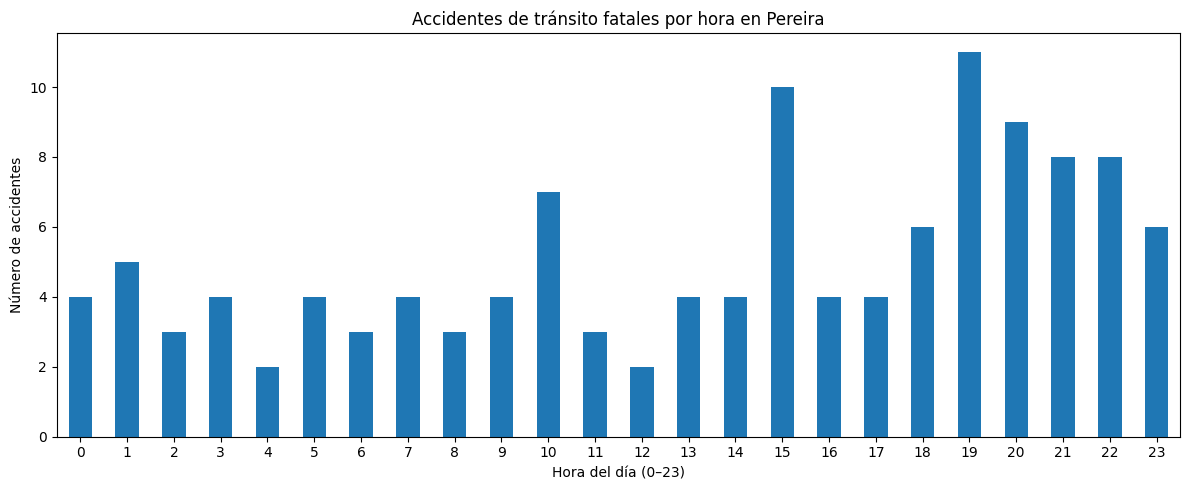

In [ ]:
col = "Hora de los Hechos(reporte)"

# 1) Convertir a datetime (convierte "No Aplica" a NaT automáticamente)
df[col] = pd.to_datetime(df[col], errors="coerce")

# 2) Extraer hora 0-23
df["hora"] = df[col].dt.hour

# 3) Filtrar solo filas con hora válida
df_filtrado = df.dropna(subset=["hora"]).copy()
df_filtrado["hora"] = df_filtrado["hora"].astype(int)

# 4) Contar por hora y asegurar 24 horas
conteo_por_hora = (
    df_filtrado["hora"]
    .value_counts()
    .sort_index()
    .reindex(range(24), fill_value=0)
)

# 5) Graficar
plt.figure(figsize=(12,5))
conteo_por_hora.plot(kind="bar")
plt.xticks(rotation=0)
plt.xlabel("Hora del día (0–23)")
plt.ylabel("Número de accidentes")
plt.title("Accidentes de tránsito fatales por hora en Pereira")
plt.tight_layout()
plt.show()

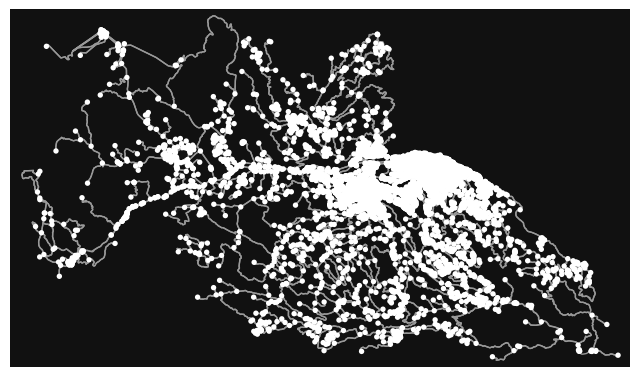

<Figure size 640x480 with 0 Axes>

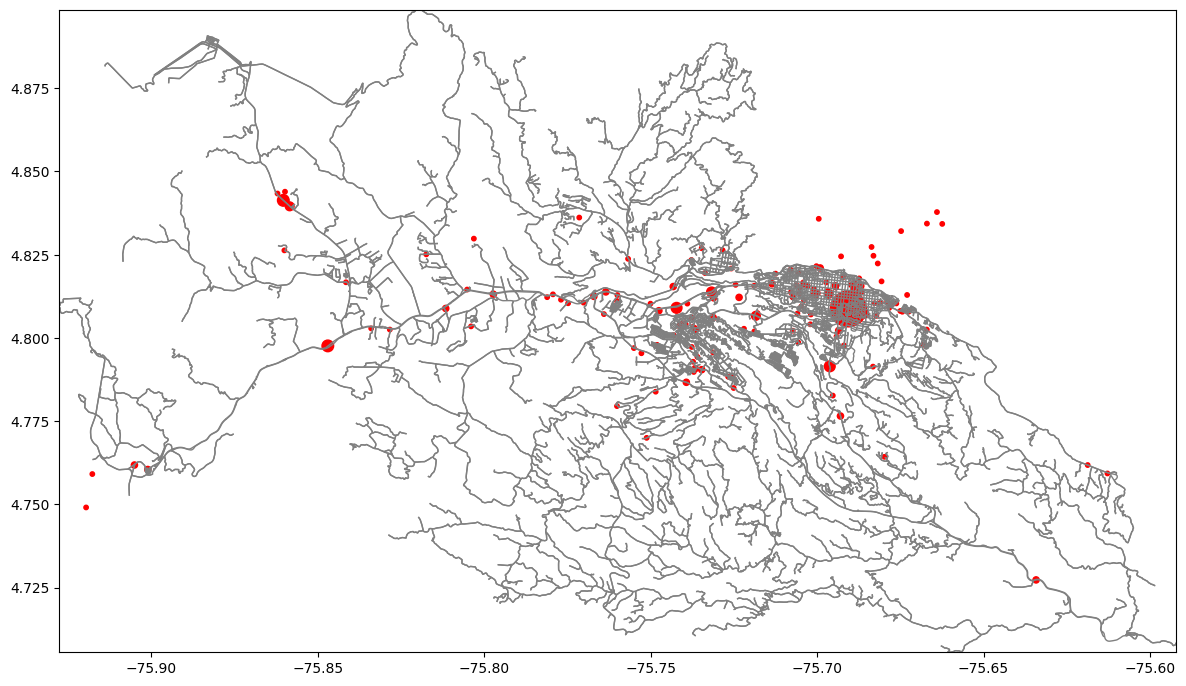

In [ ]:

# Obtener la geometría de la ciudad de Pereira
place_name = "Pereira, Risaralda, Colombia"
graph = ox.graph_from_place(place_name, network_type='drive')
fig, ax = ox.plot_graph(graph)

plt.tight_layout()
plt.show()


# Mapa de calor - Pereira

ox.settings.use_cache = True
ox.settings.log_console = True

place_name = "Pereira, Risaralda, Colombia"
graph = ox.graph_from_place(place_name, network_type='drive')

nodes, edges = ox.graph_to_gdfs(graph)

df['Longitude'] = df['Longitude'].apply(lambda x: x if -180 <= x <= 180 else x/10)
df['Latitude'] = df['Latitude'].apply(lambda x: x if -90 <= x <= 90 else x/10)

df.dropna(subset=['Latitude', 'Longitude'], inplace=True)

accident_counts = df.groupby(['Latitude', 'Longitude']).size().reset_index(name='counts')

gdf_accident_counts = gpd.GeoDataFrame(
    accident_counts,
    geometry=gpd.points_from_xy(accident_counts.Longitude, accident_counts.Latitude)
)

gdf_accident_counts.set_crs(edges.crs, inplace=True)


fig, ax = plt.subplots(figsize=(12, 12))
edges.plot(ax=ax, linewidth=1, edgecolor='grey')

gdf_accident_counts.plot(ax=ax, color='red', markersize=gdf_accident_counts['counts'] * 10)

ax.set_xlim(edges.total_bounds[[0, 2]])
ax.set_ylim(edges.total_bounds[[1, 3]])

ax.set_aspect('equal', 'box')

plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import folium
from IPython.display import IFrame, display

# =========================
# 1) CONFIGURACIÓN (AJUSTA LA RUTA)
# =========================
FILE_PATH = "/content/Fatales Pereira 2023-2025 2.xlsx"  # <-- cambia si es otra ruta
LAT_COL = "Latitude"
LON_COL = "Longitude"
OUTPUT_HTML = "mapa_accidentes_pereira.html"

MIN_RADIUS = 4
MAX_RADIUS = 28

# =========================
# 2) CARGA DE DATOS
# =========================
df = pd.read_excel(FILE_PATH)
df.columns = [c.strip() for c in df.columns]

df[LAT_COL] = pd.to_numeric(df[LAT_COL], errors="coerce")
df[LON_COL] = pd.to_numeric(df[LON_COL], errors="coerce")
df = df.dropna(subset=[LAT_COL, LON_COL]).copy()

if df.empty:
    raise ValueError("❌ No hay filas con latitud/longitud válidas para graficar.")

# =========================
# 3) AGRUPAR ACCIDENTES EN EL MISMO PUNTO
# =========================
df[LAT_COL] = df[LAT_COL].round(5)
df[LON_COL] = df[LON_COL].round(5)

grouped = (
    df.groupby([LAT_COL, LON_COL], as_index=False)
      .size()
      .rename(columns={"size": "accidentes"})
)

max_count = grouped["accidentes"].max()

def scale_radius(count):
    if max_count <= 1:
        return MIN_RADIUS
    norm = (count - 1) / (max_count - 1)
    return MIN_RADIUS + norm * (MAX_RADIUS - MIN_RADIUS)

# =========================
# 4) CREAR MAPA
# =========================
center_lat = grouped[LAT_COL].mean()
center_lon = grouped[LON_COL].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="OpenStreetMap")

# =========================
# 5) PUNTOS ROJOS CON TAMAÑO POR FRECUENCIA
# =========================
for _, row in grouped.iterrows():
    lat = float(row[LAT_COL])
    lon = float(row[LON_COL])
    count = int(row["accidentes"])

    folium.CircleMarker(
        location=[lat, lon],
        radius=scale_radius(count),
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.65,
        popup=f"Accidentes en este punto: {count}"
    ).add_to(m)

# =========================
# 6) VER EN NOTEBOOK + GUARDAR HTML
# =========================
m.save(OUTPUT_HTML)

# Mostrar como en el código anterior (render dentro del notebook)
display(m)

# Alternativa (a veces se ve mejor en Colab):
display(IFrame(OUTPUT_HTML, width=1000, height=650))